<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/02_signal_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Cell 1 — self-contained bootstrap (device, repo, imports)
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = ""  # paste a token here for this session only
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
else:
    !cd /content/deep-space-interference-ml && git pull

%cd /content/deep-space-interference-ml
!pip install -r requirements.txt -q

sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from src.channel import SignalConfig, INTERFERENCE_GENERATORS

cfg = SignalConfig()
rng = np.random.default_rng(42)
print("NSPS:", cfg.NSPS)  # should print 8

Device: cuda
Cloning into '/content/deep-space-interference-ml'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 14 (delta 2), reused 14 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 4.75 KiB | 4.75 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/deep-space-interference-ml
NSPS: 8


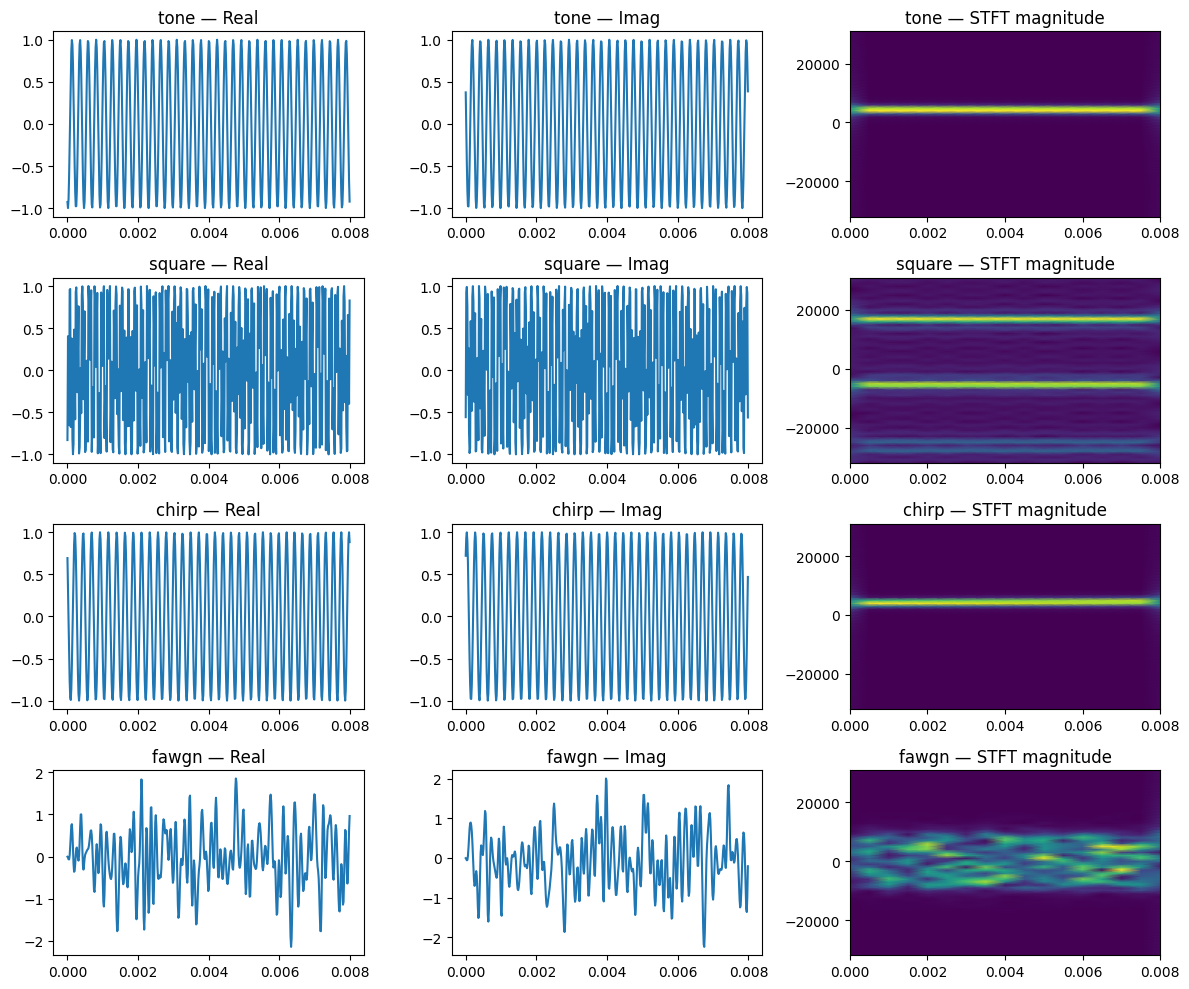

In [3]:
# Cell 2 — reproduce Figure 1: I/Q + STFT magnitude for each interference type
n_samples = 512

fig, axes = plt.subplots(len(INTERFERENCE_GENERATORS), 3, figsize=(12, 10))

for row, (name, gen) in enumerate(INTERFERENCE_GENERATORS.items()):
    z = gen(cfg, n_samples, rng)
    t = np.arange(n_samples) / cfg.Fs

    axes[row, 0].plot(t, z.real)
    axes[row, 0].set_title(f"{name} — Real")
    axes[row, 1].plot(t, z.imag)
    axes[row, 1].set_title(f"{name} — Imag")

    f, tt, Zxx = sp_signal.stft(z, fs=cfg.Fs, nperseg=64, return_onesided=False)
    f = np.fft.fftshift(f)
    Zxx = np.fft.fftshift(Zxx, axes=0)
    axes[row, 2].pcolormesh(tt, f, np.abs(Zxx), shading='gouraud')
    axes[row, 2].set_title(f"{name} — STFT magnitude")

plt.tight_layout()
plt.savefig("figures/fig1_reproduction.png", dpi=150)
plt.show()

x shape: (2048,)
label (interference present): True
SIR (dB): 16.9739747284205  SNR (dB): 10.28450257018547
Power(x): 1.1339852612292567


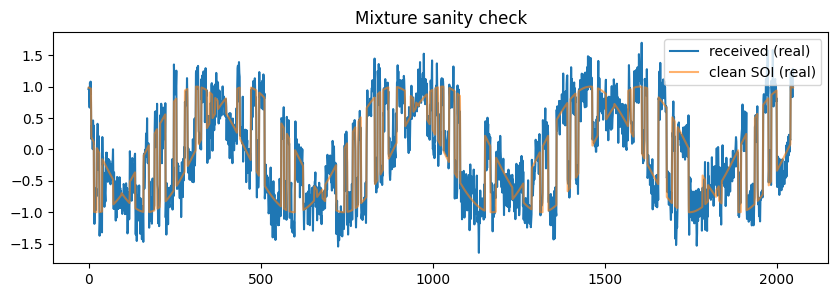

In [4]:
# Cell 3 — sanity check the full mixture pipeline (Eq. 4-6)
from src.channel import mix_signal

sample = mix_signal(cfg, n_symbols=256, rng=rng, interference_type="chirp",
                     contamination=1.0, apply_shift=True)

print("x shape:", sample["x"].shape)
print("label (interference present):", sample["label"])
print("SIR (dB):", sample["sir_db"], " SNR (dB):", sample["snr_db"])
print("Power(x):", np.mean(np.abs(sample["x"])**2))  # sanity: should be roughly O(1-3), not 0 or huge

plt.figure(figsize=(10,3))
plt.plot(sample["x"].real, label="received (real)")
plt.plot(sample["s"].real, label="clean SOI (real)", alpha=0.6)
plt.legend()
plt.title("Mixture sanity check")
plt.show()

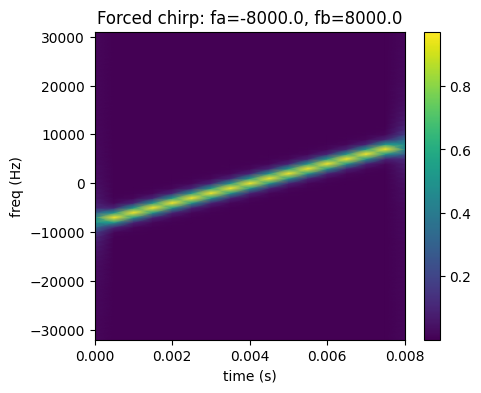

Random draw would have given fa: 4383.296776895413  fb: -977.944963967163  |fb-fa|: 5361.241740862576


In [5]:
# Diagnostic — force a wide chirp sweep to rule out "coincidental narrow draw"
n_samples = 512
n = np.arange(n_samples)
TL = n_samples / cfg.Fs

fa, fb = -cfg.Rs, cfg.Rs   # forced full-bandwidth sweep, no randomness involved
inst = 2*np.pi*(fa + (fb - fa)*n/(2*cfg.Fs*TL))*n/cfg.Fs
z_forced = np.exp(1j*inst)

f, tt, Zxx = sp_signal.stft(z_forced, fs=cfg.Fs, nperseg=64, return_onesided=False)
f = np.fft.fftshift(f)
Zxx = np.fft.fftshift(Zxx, axes=0)

plt.figure(figsize=(5,4))
plt.pcolormesh(tt, f, np.abs(Zxx), shading='gouraud')
plt.title(f"Forced chirp: fa={fa}, fb={fb}")
plt.xlabel("time (s)"); plt.ylabel("freq (Hz)")
plt.colorbar()
plt.show()

# also check what fa/fb the earlier random run actually drew
rng_check = np.random.default_rng(42)
fa_r = rng_check.uniform(-cfg.Rs, cfg.Rs)
fb_r = rng_check.uniform(-cfg.Rs, cfg.Rs)
print("Random draw would have given fa:", fa_r, " fb:", fb_r, " |fb-fa|:", abs(fb_r - fa_r))